# Tarefa

1. Replique o experimeto com o conjunto de dados `make_circles` do scikit-learn:
    ``` python
    data, _ = datasets.make_circles(n_samples=10000, noise=0.02, random_state=42)
    ```

- Treine o mesmo modelo por um mesmo número de épocas (ex.: 100) com 4  taxas de aprendizado (`lr`) diferentes: $0.1, 0.01, 0.001, 0.0001$.
    - Para cada modelo, gere 1000 amostras e produza `plotar_heatmap` (densidade + amostras).
    - Capture a perda por época.
    - Construa em um único gráfico: época x perda para os 4 valores.
    - Analise as curvas.
    - Comente sobre a geração dos dados sintéticos desses modelos.

2. Utilizando o seguinte conjunto de dados:

    ``` python
    X1, _  = datasets.make_circles(n_samples=10000, noise=0.02, random_state=42)
    X2, _ = datasets.make_moons(10000, noise=0.05)
    X3, _ = datasets.make_blobs(10000, cluster_std=0.05, center_box=(-3,3), centers=np.array([[0,0], [2, -1], [3, 0]]))
    X2[:, 0] += 1
    X2[:, 1] += 1.5
    data = np.vstack((X1, X2, X3))
    ```

- Fixe `lr = 1e-4` e treine 3 arquiteturas RelNVP:
    - 2 camadas de acoplamento (baseline)
    - 4 camadas de acoplamento
    - 6 camadas de acoplamento
 - Para cada modelo, gere 1000 amostras e produza `plotar_heatmap` (densidade + amostras).
- Capture a perda por época.
- Construa em um único gráfico: época x perda para os 3 valores.

- Analise as curvas.
- Comente sobre a geração dos dados sintéticos desses modelos.

**Entregáveis**:
1. Notebook `.ipynb`.
2. Relatório `.pdf`:

    - Reporte e comente os resultados no relatório.

    - Incluir gráficos gerados.

# Importações

In [1]:
import torch                                            # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                                    # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader, TensorDataset  # Importa o DataLoader (carregamento de lotes/batches) e o TensorDataset (wrap de tensores como dataset)
from torchinfo import summary                           # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
from sklearn import datasets                            # Utilizado para gerar dados sintéticos (ex.: make_moons, make_circles, make_blobs, etc.)
from sklearn.preprocessing import StandardScaler        # Normalização z-score (média 0, desvio 1) para cada feature
import numpy as np                                      # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt                         # Importa o módulo de visualização matplotlib para gerar gráficos.
import time                                             # Medição de tempos (ex.: duração por época, tempo total de treino, etc.)
from tqdm.auto import tqdm                              # Barra de progresso que se adapta ao ambiente (Jupyter ou terminal)
import os                                               # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"             # Ajusta a variável de ambiente para evitar erros ao carregar múltiplas bibliotecas MKL

In [2]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

# Dados

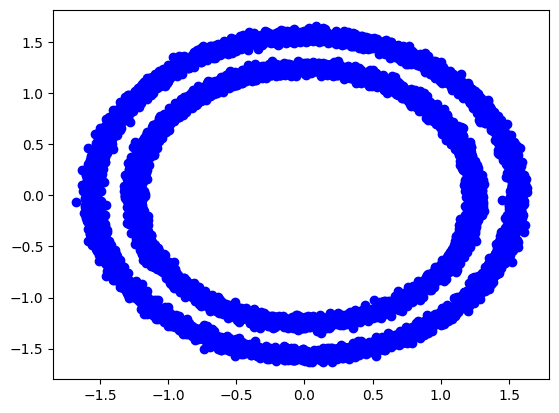

In [3]:
data, _ = datasets.make_circles(n_samples=10000, noise=0.02, random_state=42)
# Normalização (média 0, variância 1)
scaler = StandardScaler()
normalized_data = scaler.fit_transform(data)

# Visualização dos dados (gráfico de dispersão)
plt.figure()
plt.scatter(normalized_data[:, 0], normalized_data[:, 1], c="b")
plt.show()

# DataLoader para treinamento
batch_size = 256
tensor_data = torch.tensor(normalized_data, dtype=torch.float32)
dataset = TensorDataset(tensor_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# RealNVP

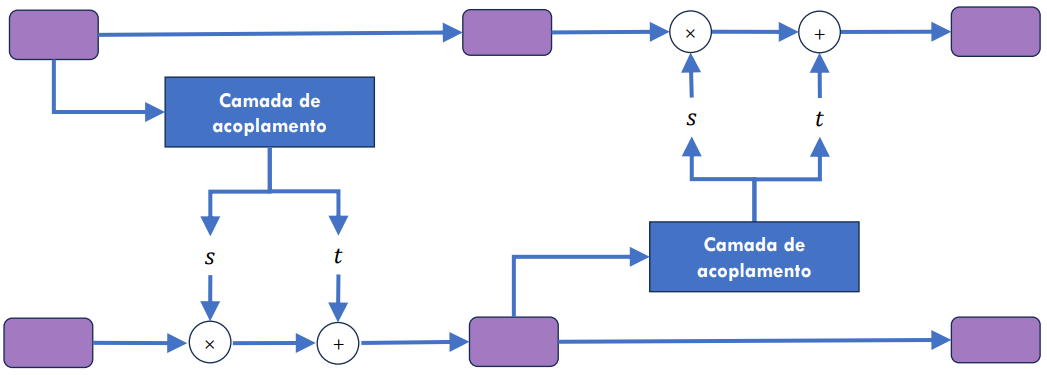

## Camada de acoplamento

In [5]:
class CamadaDeAcoplamento(nn.Module):
    """
    Camada de acoplamento usada em fluxos de normalização (RealNVP).
    Divide o vetor de entrada em duas partes (definidas pela máscara)
    e aplica transformações de escala (s) e translação (t) apenas
    sobre a parte livre, garantindo que a transformação seja invertível.

    Parâmetros
    ----------
    input_dim : int
        Dimensão do vetor de entrada.
    hidden_dim : int
        Número de unidades nas camadas ocultas das redes de escala e translação.
    """

    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()

        # -------- rede de escala (s) --------
        self.rede_escala = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()
        )

        # -------- rede de translação (t) --------
        self.rede_translacao = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(
        self,
        x: torch.Tensor,
        mascara: torch.Tensor,
        direcao_generativa: bool = True
    ):
        """
        Executa a transformação direta (z -> x) ou inversa (x -> z).

        Parâmetros
        ----------
        x : Tensor
            Lote de vetores de dimensão input_dim.
        mascara : Tensor
            Máscara binária (mesma forma de x) que indica quais dimensões ficam fixas (1) e quais são transformadas (0).
        direcao_generativa : bool, opcional (default = True)
            True: direção gerativa (z -> x).
            False: direção de normalização (x -> z), usado no cálculo da log-verossimilhança durante o treinamento.

        Retorna
        -------
        saida : Tensor
            Vetor transformado.
        logdet : Tensor
            Log-determinante do Jacobiano da transformação aplicada a cada amostra do lote.
        """

        mascara_inversa = (1 - mascara)                     # máscara para as dimensões que serão transformadas com translação e escala
        x_fixo          = x * mascara                       # parte que fica inalterada
        s = self.rede_escala(x_fixo)     * mascara_inversa  # calcula escala (s) apenas sobre x_fixo
        t = self.rede_translacao(x_fixo) * mascara_inversa  # calcula translação (t) apenas sobre x_fixo

        if direcao_generativa:
            x_livre = mascara_inversa * (x * torch.exp(s) + t)
            saida   = x_fixo + x_livre
            logdet  = s.sum(dim=-1)      # shape: (batch_size,)

        else:
            x_livre = mascara_inversa * ((x - t) * torch.exp(-s))
            saida   = x_fixo + x_livre
            logdet  = -s.sum(dim=-1)     # shape: (batch_size,)

        return saida, logdet

## Modelo

In [6]:
class RealNVP(nn.Module):
    """
    Implementação do modelo RealNVP.

    Parâmetros
    ----------
    input_dim : int
        Dimensão dos vetores de dados.
    hidden_dim : int
        Dimensão das camadas ocultas nas redes s-t.
    num_camadas_acoplamento : int
        Quantidade de camadas de acoplamento no fluxo.
    """

    def __init__(self,
                 input_dim: int,
                 hidden_dim: int,
                 num_camadas_acoplamento: int):

        super().__init__()

        self.num_camadas_acoplamento = num_camadas_acoplamento

        # Distribuição base N(0, I) (registrada como buffer para mover junto ao modelo)
        self.register_buffer("loc", torch.zeros(input_dim))
        self.register_buffer("cov", torch.eye(input_dim))

        # Máscaras 0/1 que determinam quais dimensões cada camada transforma (registrada como buffer para mover junto ao modelo)
        n_fixas = input_dim // 2
        mascara = torch.cat([torch.ones(n_fixas), torch.zeros(input_dim - n_fixas)])      # [1, ..., 1, 0, ..., 0]
        mascara_inversa = 1.0 - mascara                                                   # [0, ..., 0, 1, ..., 1]
        mascaras = (
            torch.stack([mascara_inversa, mascara] * (num_camadas_acoplamento // 2), dim=0)
            .to(torch.float32)
        ) # repete o par [mascara_inversa, mascara] até completar o número de camadas
        self.register_buffer("mascaras", mascaras)  # shape: (num_camadas_acoplamento, input_dim)

        # Lista de camadas de acoplamento.
        self.lista_camadas = nn.ModuleList(
            [CamadaDeAcoplamento(input_dim, hidden_dim) for _ in range(num_camadas_acoplamento)]
        )


    def forward(self,
                x: torch.Tensor,
                direcao_generativa: bool = False):
        """
        Passa o lote por todas as camadas.

        direcao_generativa = True  -> direção generativa        (z -> x)
        direcao_generativa = False -> direção de normalização   (x -> z)  (padrão)

        Retorna
        -------
        Se direcao_generativa = True:
            x_transformado : Tensor
        Caso contrário:
            z              : Tensor
            logdet_total   : Tensor  (soma dos log-determinantes por amostra)
        """

        # -------------------------------------------------------------------------
        # DIREÇÃO GERATIVA (z -> x)
        # -------------------------------------------------------------------------
        if direcao_generativa:
            for mascara, camada in zip(self.mascaras, self.lista_camadas):
                x, _ = camada(x, mascara, direcao_generativa=True)
            return x                                # não precisamos de log-det

        # -------------------------------------------------------------------------
        # DIREÇÃO DE NORMALIZAÇÃO (z <- x)
        # -------------------------------------------------------------------------
        else:
            logdet_total = x.new_zeros(x.size(0))          # (batch,)
            for mascara, camada in reversed(list(zip(self.mascaras, self.lista_camadas))):
                x, logdet = camada(x, mascara, direcao_generativa=False)
                logdet_total += logdet
            return x, logdet_total

    # -------------------------------------------------------------------------
    #   FUNÇÃO DE PERDA
    # -------------------------------------------------------------------------
    def perda_log_verossimilhanca(self, x: torch.Tensor) -> torch.Tensor:
        """
        Calcula NLL = -log p(x) (média do negativo da log-verossimilhança), valor que deve ser MINIMIZADO durante o treino.
        """
        distribuicao_base = torch.distributions.MultivariateNormal(self.loc, covariance_matrix=self.cov)
        z, logdet = self.forward(x, direcao_generativa=False)
        log_prob  = distribuicao_base.log_prob(z) + logdet
        return -(log_prob.mean())

    # -------------------------------------------------------------------------
    #   AMOSTRAGEM
    # -------------------------------------------------------------------------
    def amostrar(self, n_amostras: int, dispositivo: torch.device | None = None) -> torch.Tensor:
        """
        Gera 'n_amostras' no espaço dos dados X.

        Retorna
        -------
        Tensor shape (n_amostras, dim_entrada) já na CPU, pronto para uso.
        """
        if dispositivo is None:
            dispositivo = next(self.parameters()).device

        distribuicao_base = torch.distributions.MultivariateNormal(self.loc, covariance_matrix=self.cov)
        z = distribuicao_base.sample((n_amostras,)).to(dispositivo)        # amostra da base
        x = self.forward(z, direcao_generativa=True)                       # z -> x
        return x.detach().cpu()

    # -------------------------------------------------------------------------
    #  MAPA DE CALOR DA DENSIDADE (COM PONTOS AMOSTRADOS)
    # -------------------------------------------------------------------------
    def plotar_heatmap(
        self,
        limites: tuple[float, float, float, float] = (-2, 2, -2, 2),
        resolucao: int = 200,
        n_amostras: int = 1000,
        ax: plt.Axes | None = None,
        cmap: str = "viridis",
    ):
        """
        Desenha um mapa de calor da densidade modelada + pontos amostrados.

        limites : (xmin, xmax, ymin, ymax)
        resolucao : número de pontos por eixo para a grade 2-D
        n_amostras : pontos sorteados a serem sobrepostos
        ax : eixo Matplotlib existente (opcional)
        cmap : colormap para o heatmap
        """

        distribuicao_base = torch.distributions.MultivariateNormal(self.loc, covariance_matrix=self.cov)

        xmin, xmax, ymin, ymax = limites
        device = next(self.parameters()).device

        # ---------- cria grade 2-D ----------
        xs = torch.linspace(xmin, xmax, resolucao, device=device)
        ys = torch.linspace(ymin, ymax, resolucao, device=device)
        grid_x, grid_y = torch.meshgrid(xs, ys, indexing="xy")
        pontos_grade = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)

        # ---------- densidade p(x) ----------
        with torch.no_grad():
            z, logdet = self.forward(pontos_grade, direcao_generativa=False)
            log_prob = distribuicao_base.log_prob(z) + logdet
            densidade = log_prob.exp()
            densidade = densidade.cpu().reshape(resolucao, resolucao)

        # ---------- prepara figura ----------
        if ax is None:
            _, ax = plt.subplots(figsize=(6, 5))

        im = ax.imshow(
            densidade,
            origin="lower",
            extent=[xmin, xmax, ymin, ymax],
            cmap=cmap,
            aspect="auto",
        )
        plt.colorbar(im, ax=ax, label="p(x)")

        # ---------- amostras sobrepostas ----------
        amostras = self.amostrar(n_amostras)
        ax.scatter(amostras[:, 0], amostras[:, 1], color="red", alpha=0.35, s=8)
        ax.set_xlim([xmin, xmax])
        ax.set_ylim([ymin, ymax])
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.set_title("Densidade estimada e amostras do RealNVP")
        plt.show()

# Treinamento

## Instanciar o modelo

In [19]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Usando {device}.")  # Exibe qual dispositivo está sendo utilizado
model = RealNVP(input_dim=2, hidden_dim=256, num_camadas_acoplamento=2).to(device)
print('Máscaras:')
print(f'{model.mascaras}')
print(f'Shape = (num_camadas_acoplamento, input_dim) = {model.mascaras.shape}')

Usando cuda.
Máscaras:
tensor([[0., 1.],
        [1., 0.]], device='cuda:0')
Shape = (num_camadas_acoplamento, input_dim) = torch.Size([2, 2])


In [20]:
summary(model,
        input_size=(1, 2),  # (batch_size = 1, input_dim = 2)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=4)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
RealNVP                                  [1, 2]                    [1, 2]                    --                        True
├─ModuleList: 1-1                        --                        --                        --                        True
│    └─CamadaDeAcoplamento: 2-1          [1, 2]                    [1, 2]                    --                        True
│    │    └─Sequential: 3-1              [1, 2]                    [1, 2]                    --                        True
│    │    │    └─Linear: 4-1             [1, 2]                    [1, 256]                  768                       True
│    │    │    └─ReLU: 4-2               [1, 256]                  [1, 256]                  --                        --
│    │    │    └─Linear: 4-3             [1, 256]                  [1, 256]                  65,792                    True
│    

## Otimizador

In [16]:
learning_rate = 1e-1
weight_decay = 1e-2
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

## Amostragem antes do treinamento

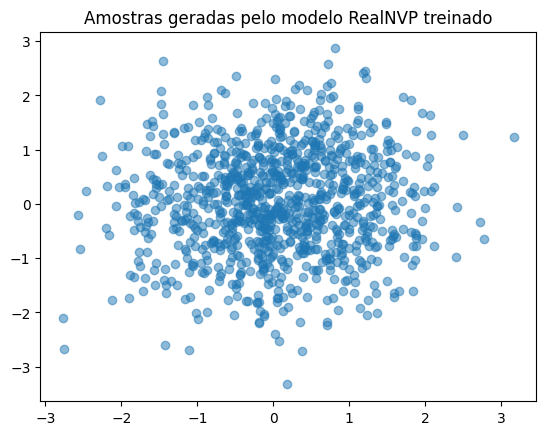

In [21]:
model.eval()
amostras = model.amostrar(1000)
plt.scatter(amostras[:, 0], amostras[:, 1], alpha=0.5)
plt.title("Amostras geradas pelo modelo RealNVP treinado")
plt.show()

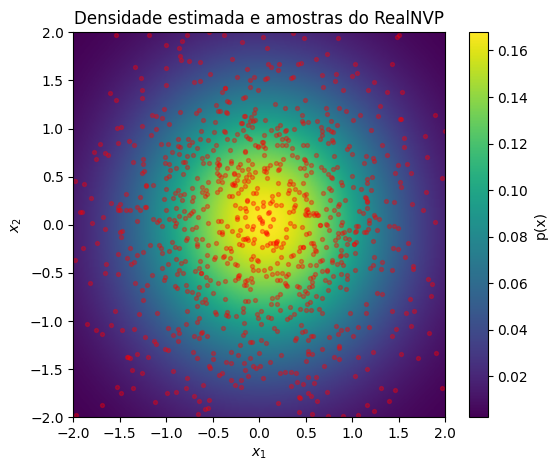

In [22]:
model.plotar_heatmap(resolucao=300, n_amostras=1000)

## Loop de treinamento

In [23]:
tic = time.time()
n_epochs = 100 #300

full_losses = []

epochs_bar = tqdm(range(n_epochs),
                  desc="Treinando",
                  unit="época",
                  dynamic_ncols=True,
                  leave=True)

for epoch in epochs_bar:

    epoch_start = time.time()
    losses = []

    for (batch,) in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        loss = model.perda_log_verossimilhanca(batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    epoch_end = time.time()

    # métricas da época
    t_epoch = epoch_end - epoch_start
    mean_loss  = float(np.mean(losses))
    t_total  = (time.time() - tic) / 60.0

    # atualiza o texto na barra
    epochs_bar.set_description(f"Época {epoch+1}/{n_epochs}")
    epochs_bar.set_postfix(perda=f"{mean_loss:.4f}", t_epoca=f"{t_epoch:.2f}s", t_total=f"{t_total:.2f}min")

    full_losses.extend(losses)

torch.save(model.state_dict(), f"realnvp_circulos_{learning_rate}.pth")

Treinando:   0%|          | 0/100 [00:00<?, ?época/s]

In [24]:
# Salvar lista de losses
import pickle

with open(f"losses_circulos_{learning_rate}.pkl", "wb") as f:
    pickle.dump(full_losses, f)

## Amostragem pós treinamento

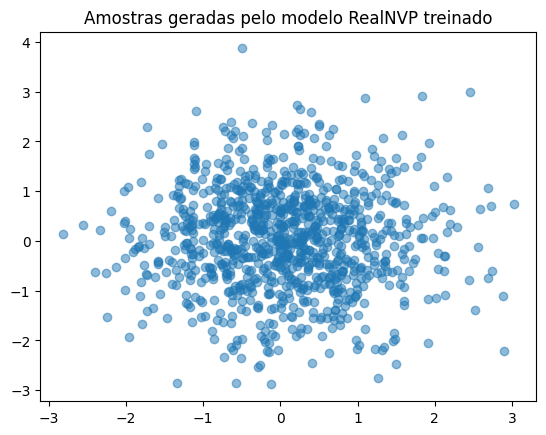

In [25]:
model.eval()
amostras = model.amostrar(1000)
plt.scatter(amostras[:, 0], amostras[:, 1], alpha=0.5)
plt.title("Amostras geradas pelo modelo RealNVP treinado")
plt.show()

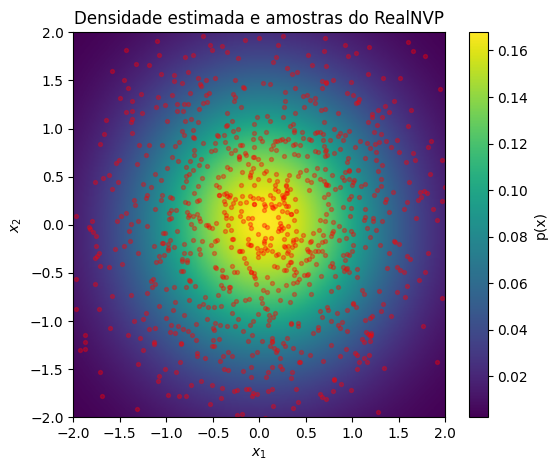

In [26]:
model.plotar_heatmap(resolucao=300, n_amostras=1000)